# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [57]:
from __future__ import annotations

import torch
from torch import nn

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [58]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
            nn.init.zeros_(self.bias)
        else:
            self.bias = None
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        if self.bias is not None: 
            return x @ self.weight.t() + self.bias
        else: 
            return x @ self.weight.t()

In [59]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim

        self.weight = nn.Parameter(torch.Tensor(num_embeddings, embedding_dim))

        

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weight[idx]

In [60]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        if self.training and self.p>0:
            mask = (torch.rand_like(x) > self.p).float()
            return (x * mask) / (1 - self.p)
        else: return x

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [61]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.eps = eps
        self.elementwise_affine = elementwise_affine
        if self.elementwise_affine:
            self.weight = nn.Parameter(torch.Tensor(normalized_shape))
            self.bias = nn.Parameter(torch.Tensor(normalized_shape))

            nn.init.ones_(self.weight)
            nn.init.zeros_(self.bias)
        else:
            self.weight = None
            self.bias = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        if self.elementwise_affine:
            return self.weight * x_norm + self.bias
        else: x_norm

In [62]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.Tensor(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        ms = (x ** 2).mean(dim=-1, keepdim=True)
        rms = torch.sqrt(ms + self.eps)
        return self.weight * (x / rms)


## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [63]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        # TODO: build modules (list of Linear + activation)
        # Optionally insert LayerNorm between layers.
        self.layers = nn.ModuleList()
        
        for i in range(depth):
            layer_in = in_dim if i == 0 else hidden_dim
            layer_out = out_dim if i == depth - 1 else hidden_dim
            self.layers.append(Linear(layer_in, layer_out))
            if i < depth - 1:
                    if use_layernorm:
                        self.layers.append(LayerNorm(hidden_dim))
                    self.layers.append(nn.GELU())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
                    x = layer(x)
        return x

In [64]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        # TODO: create two Linear layers and choose an activation (GELU)
        self.w_1 = Linear(d_model, d_ff)
        self.w_2 = Linear(d_ff, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.w_1(x)
        x = nn.functional.gelu(x)
        x = self.w_2(x)
        return x

In [65]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn 

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        # TODO: return x + fn(x, ...)
        return x + self.fn(x, *args, **kwargs)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [66]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [67]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

In [68]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    log_probs = torch.nn.functional.log_softmax(logits, dim=1)
    return torch.nn.functional.nll_loss(log_probs, targets)

In [69]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        self.proj = Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        return self.proj(x)

In [70]:
def accuracy(loader):
    # TODO: You can use this function to evaluate your model accuracy.
    global model
    with torch.no_grad():
        model.eval()
        correct = 0
        total = 0
        
        for images, labels in loader:

            logits = model(images)
            
            preds = torch.argmax(logits, dim=1)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
        model.train()
        return correct / total

In [71]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loss_list = []
    for epoch in range(epochs):
        model.train()
        for images, labels in train_data_loader:
            
            #FPass
            logits = model(images)
            loss = cross_entropy_from_logits(logits, labels)
            #BwPass
            optimizer.zero_grad()
            loss.backward()
            # parameters
            optimizer.step()

            train_loss_list.append(loss.item())
        test_acc = accuracy(test_data_loader)
        print(f"epoch {epoch+1}/{epochs} loss: {loss.item():.4f}  testacc: {test_acc:.4f}")
    return train_loss_list



In [72]:

class MNISTModel(nn.Module):
    def __init__(self, hidden_dim: int, depth: int):
        super().__init__()
        self.mlp_and_residual = Residual(MLP(in_dim=784, hidden_dim=hidden_dim, out_dim=784, depth=depth, use_layernorm=True))
        self.head = ClassificationHead(d_in=784, num_classes=10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        x = x.view(x.size(0), -1)
        x = self.mlp_and_residual(x)
        return self.head(x)

model = MNISTModel(hidden_dim=256, depth=2)

# Train
losses = train_classifier(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=test_loader,
    lr=1e-3,
    epochs=5
)

epoch 1/5 loss: 0.0797  testacc: 0.9637
epoch 2/5 loss: 0.0348  testacc: 0.9713
epoch 3/5 loss: 0.0052  testacc: 0.9747
epoch 4/5 loss: 0.0283  testacc: 0.9789
epoch 5/5 loss: 0.0517  testacc: 0.9755


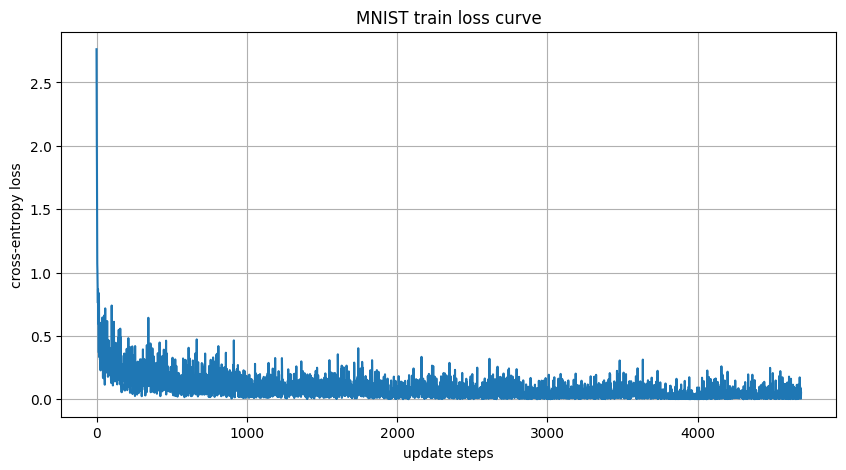

In [73]:
import matplotlib.pyplot as plt

def plot_loss(train_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses)
    plt.title("MNIST train loss curve")
    plt.xlabel("update steps")
    plt.ylabel("cross-entropy loss")
    plt.grid(True)
    plt.show()


plot_loss(losses)